In [1]:
import os
import io
import requests
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rocks
from astropy.coordinates import SkyCoord
import astropy.constants as const
from astropy.timeseries import LombScargleMultiband


from fink_utils.sso.spins import (
    estimate_sso_params,
    func_hg1g2,
    func_hg1g2_with_spin,
)

from fink_utils.sso.periods import (
    estimate_synodic_period,
    extract_physical_parameters,
    compute_residuals,
)  # v0.21.0 or more

from scipy.optimize import least_squares
from scipy import linalg

import sys

sys.path.append("..")
import ssptools

# import seaborn as sns
# sns.set_context("poster")

In [2]:
fink_colors = ["#15284F", "#F5622E"]

# Fitting functions
adapted from existing functions in fink_utils

In [3]:
def synodic_to_sidereal(synodic_period, X):
    """
    Convert synodic rotation period to sidereal rotation period.

    TBD

    Parameters
    ----------
    synodic_period : float
        Synodic rotation period in days.

    Returns
    -------
    sidereal_period : float
        Sidereal rotation period in days.
    """
    sidereal_period = synodic_period
    return sidereal_period

In [4]:
def estimate_axes_ratio(residuals, R):
    """Estimate the axes ratio of a SSO from the residuals of the sHG1G2 model
    and its oblateness R.

    Parameters
    ----------
    residuals: np.array
        Residuals (observed - model) of the SSO with sHG1G2 model
    R: float
        Oblateness parameter of the sHG1G2 model

    Returns
    -------
    a_b, a_c: float
        a/b and a/c axes ratio
    """

    # Estimate the amplitude of the lightcurve from residuals
    # Taken at 2 sigma
    amplitude = np.std(residuals) * 2.0

    # Estimate the a/b ratio
    a_b = 10 ** (0.4 * (amplitude * 2))

    # Estimate the a/c ratio (and force c<b)
    a_c = (a_b + 1) / (2 * R)
    if a_c < a_b:
        a_c = a_b

    return a_b, a_c

In [5]:
# Speed of light in AU/day
c_speed = const.c.to("au/day").value


def estimate_synodic_period_ltc(
    ssnamenr: str = None,
    pdf=None,
    phyparam=None,
    flavor="SHG1G2",
    Nterms_base=1,
    Nterms_band=1,
    period_range=(0.05, 1.2),
    sb_method="auto",
    return_extra_info=False,
):
    """Estimate the synodic period of a Solar System object seen by Fink

    Parameters
    ----------
    ssnamenr: str
        SSO number (we do not resolve name yet)
    pdf: pandas DataFrame, optional
        Pandas DataFrame with Fink SSO data for one object.
        If not specified, data will be downloaded from Fink servers
        using `ssnamenr`.
    phyparam: dict, optional
        Dictionary containing physical properties (phase curve, etc.)
        of the object. If not specified, they will be recomputed
        from the data.
    flavor: str, optional
        Model flavor: SHG1G2 (default), HG1G2, HG12, or HG
    Nterms_base: int, optional
        Number of frequency terms to use for the
        base model common to all bands. Default is 1.
    Nterms_band: int, optional
        Number of frequency terms to use for the
        residuals between the base model and
        each individual band. Default is 1.
    period_range: tupe of float, optional
        (min_period, max_period) for the search, in days.
        Default is (0.05, 1.2), that is between
        1.2 hours and 28.8 hours.
    sb_method: str, optional
        Specify the single-band lomb scargle implementation to use.
        See https://docs.astropy.org/en/stable/api/astropy.timeseries.LombScargleMultiband.html#astropy.timeseries.LombScargleMultiband.autopower
        If nifty-ls is installed, one can also specify fastnifty. Although
        in this case it does not work yet for Nterms_* higher than 1.
    return_extra_info: bool, optional
        If True, returns also the fitted model, and the original
        SSO data used for the fit. Default is False.

    Returns
    -------
    best_period: float
        Best period found, in hour
    reduced_chi2: float
        Reduced chi2 (chi2 per ddof)
    model: object, optional
        If `return_extra_info`, the fitted model is returned
    pdf: pandas DataFrame, optional
        If `return_extra_info`, the original data is returned.
        Note that the extra field "residuals" contains the
        `observation - model` data, in magnitude.

    Examples
    --------
    >>> ssnamenr = 2363
    >>> P, chi2 = estimate_synodic_period(ssnamenr, flavor="SHG1G2", Nterms_base=2)
    >>> assert int(P) == 20, P

    >>> P_HG, chi2_HG = estimate_synodic_period(ssnamenr, flavor="HG", Nterms_base=2)
    >>> assert chi2 < chi2_HG, (chi2, chi2_HG)


    One can also use the nifty-ls implementation (faster and more accurate)
    # TODO: check alias between astropy and nifty-ls...
    >>> P_nifty, _ = estimate_synodic_period(ssnamenr, flavor="SHG1G2", sb_method="fastnifty")
    >>> assert np.isclose(P, 2 * P_nifty, rtol=1e-1), (P, P_nifty)

    One can also directly specify the Pandas dataframe with Fink data:
    # TODO: check alias between astropy and nifty-ls...
    >>> r = requests.post("https://fink-portal.org/api/v1/sso", json={"n_or_d": ssnamenr, "withEphem": True, "output-format": "json"})
    >>> pdf = pd.read_json(io.BytesIO(r.content))
    >>> P_from_pdf, _ = estimate_synodic_period(pdf=pdf, flavor="SHG1G2")
    >>> assert np.isclose(P, 2 * P_from_pdf, rtol=1e-1), (P, P_from_pdf)
    """
    if pdf is None:
        if ssnamenr is not None:
            # TODO: use quaero
            r = requests.post(
                "https://fink-portal.org/api/v1/sso",
                json={"n_or_d": ssnamenr, "withEphem": True, "output-format": "json"},
            )
        else:
            _LOG.error("You need to specify either `ssnamenr` or `pdf`.")

        pdf = pd.read_json(io.BytesIO(r.content))

    if phyparam is None:
        # get the physical parameters with the latest data
        phyparam = extract_physical_parameters(pdf, flavor)

    # Compute the residuals (obs - model)
    residuals = compute_residuals(pdf, flavor, phyparam)

    pdf["jd_ltc"] = pdf["i:jd"] - pdf["Dobs"] / c_speed

    model = LombScargleMultiband(
        pdf["jd_ltc"],
        residuals,
        pdf["i:fid"],
        pdf["i:sigmapsf"],
        nterms_base=Nterms_base,
        nterms_band=Nterms_band,
    )

    frequency, power = model.autopower(
        method="fast",
        sb_method=sb_method,
        minimum_frequency=1 / period_range[1],
        maximum_frequency=1 / period_range[0],
    )
    freq_maxpower = frequency[np.argmax(power)]
    best_period = 1 / freq_maxpower

    out = model.model(pdf["jd_ltc"].to_numpy(), freq_maxpower)
    prediction = np.zeros_like(residuals)
    for index, filt in enumerate(pdf["i:fid"].unique()):
        if filt == 3:
            continue
        cond = pdf["i:fid"] == filt
        prediction[cond] = out[index][cond]

    chi2 = np.sum(((residuals - prediction) / pdf["i:sigmapsf"].to_numpy()) ** 2)
    reduced_chi2 = chi2 / len(residuals - 1)

    if return_extra_info:
        pdf["residuals"] = residuals
        return best_period * 24, reduced_chi2, frequency, power, model, pdf
    else:
        return best_period * 24, reduced_chi2

In [6]:
def cos_aspect_angle(ra, dec, ra0, dec0):
    """
    Compute the cosine of the aspect angle from the coordinates of the target and the coordinates of its pole.

    Parameters:
    ra (float): Right ascension of the target in radians.
    dec (float): Declination of the target in radians.
    ra0 (float): Right ascension of the pole in radians.
    dec0 (float): Declination of the pole in radians.

    Returns:
    float: The cosine of the aspect angle
    """

    return np.sin(dec) * np.sin(dec0) + np.cos(dec) * np.cos(dec0) * np.cos(ra - ra0)


def rotation_phase(t, W0, W1, t0):
    """
    Compute the rotational phase, from the location of the prime meridian at
    at reference epoch (W0, t0), and an angular velocity (W1)

    Parameters:
    t (float): Time (JD)
    W0 (float): Location of the prime meridian at reference epoch (radian)
    W1 (float): Angular velocity of the target in radians/day.
    t0 (float): Reference epoch (JD)

    Returns:
    float: The rotational phase W (radian)
    """
    return W0 + W1 * (t - t0)


def subobserver_longitude(ra, dec, ra0, dec0, W):
    """
    Compute the subobserver longitude (radian) from the coordinates of the target, the coordinates of its pole, and its rotation phase

    Parameters:
    ra (float): Right ascension of the target in radians.
    dec (float): Declination of the target in radians.
    ra0 (float): Right ascension of the pole in radians.
    dec0 (float): Declination of the pole in radians.
    W (float): Rotation phase of the target in radians.

    Returns:
    float: The subobserver longitude in radians.
    """

    x = -np.cos(dec0) * np.sin(dec) + np.sin(dec0) * np.cos(dec) * np.cos(ra - ra0)
    y = -np.cos(dec) * np.sin(ra - ra0)
    return W - np.arctan2(x, y)

In [7]:
def func_sshg1g2(pha, h, g1, g2, alpha0, delta0, period, a_b, a_c, phi0):
    """Return f(H, G1, G2, R, alpha0, delta0) part of the lightcurve in mag space

    Parameters
    ----------
    pha: array-like [4, N]
        List containing [phase angle in radians, RA in radians, Dec in radians, time (jd)]
    h: float
        Absolute magnitude in mag
    G1: float
        G1 parameter (no unit)
    G2: float
        G2 parameter (no unit)
    alpha0: float
        RA of the spin (radian)
    delta0: float
        Dec of the spin (radian)
    period: float
        Spin period (days)
    a_b: float
        Equatorial axes ratio
    a_c: float
        Polar axes ratio
    phi0: float
        Initial rotation phase at reference time t0 (radian)
    t0: float
        Reference time (jd)

    Returns
    -------
    out: array of floats
        H - 2.5 log(f(G1G2)) - 2.5 log(f(spin, shape))
    """
    ph = pha[0]
    ra = pha[1]
    dec = pha[2]
    ep = pha[3]

    # TBD: For the time being, we fix the reference time
    # Time( '2022-01-01T00:00:00', format='isot', scale='utc').jd
    # Kinda middle of ZTF
    t0 = 2459580.50000000

    # Standard HG1G2 part: h + f(alpha, G1, G2)
    func1 = func_hg1g2(ph, h, g1, g2)

    # Spin part
    cos_aspect = cos_aspect_angle(ra, dec, alpha0, delta0)
    cos_aspect_2 = cos_aspect**2
    sin_aspect_2 = 1 - cos_aspect_2

    # V1: Synodic
    # rot_phase = (2 * np.pi * (ep - t0) / period + phi0) % (2 * np.pi)

    # V2: Sidereal
    W = rotation_phase(ep, phi0, 2 * np.pi / period, t0)
    rot_phase = subobserver_longitude(ra, dec, alpha0, delta0, W)

    # new
    # https://ui.adsabs.harvard.edu/abs/1985A%26A...149..186P/abstract
    func2 = np.sqrt(
        sin_aspect_2 * (np.cos(rot_phase) ** 2 + (a_b**2) * np.sin(rot_phase) ** 2)
        + cos_aspect_2 * a_c**2
    )
    func2 = -2.5 * np.log10(func2)

    return func1 + func2

In [8]:
def build_eqs_for_spin_shape(x, filters, ph, ra, dec, jd, rhs):
    """Build the system of equations to solve using the HG1G2 + spin model

    Parameters
    ----------
    x: list
        List of parameters to fit for
    filters: np.array
        Array of size N containing the filtername for each measurement
    ph: np.array
        Array of size N containing phase angles
    ra: np.array
        Array of size N containing the RA (radian)
    dec: np.array
        Array of size N containing the Dec (radian)
    jd: np.array
        Array of size N containing the time of the measurements (jd)
    rhs: np.array
        Array of size N containing the actual measurements (magnitude)

    Returns
    -------
    out: np.array
        Array of size N containing (model - y)

    Notes
    -----
    the input `x` should start with filter independent variables,
    that is (alpha, delta, period, a/b, a/c, phi0), followed by filter dependent variables,
    that is (H, G1, G2). For example with two bands g & r:

    ```
    x = [
        alpha, delta, period, a_b, a_c, phi0,
        h_g, g_1_g, g_2_g,
        h_r, g_1_r, g_2_r
    ]
    ```

    """
    alpha, delta, period, a_b, a_c, phi0 = x[0:6]
    filternames = np.unique(filters)

    params = x[6:]
    nparams = len(params) / len(filternames)
    assert int(nparams) == nparams, "You need to input all parameters for all bands"

    params_per_band = np.reshape(params, (len(filternames), int(nparams)))
    eqs = []
    for index, filtername in enumerate(filternames):
        mask = filters == filtername

        myfunc = (
            func_sshg1g2(
                np.vstack(
                    [
                        ph[mask].tolist(),
                        ra[mask].tolist(),
                        dec[mask].tolist(),
                        jd[mask].tolist(),
                    ]
                ),
                params_per_band[index][0],
                params_per_band[index][1],
                params_per_band[index][2],
                alpha,
                delta,
                period,
                a_b,
                a_c,
                phi0,
            )
            - rhs[mask]
        )

        eqs = np.concatenate((eqs, myfunc))

    return np.ravel(eqs)

In [9]:
def fit_spin_shape(
    magpsf_red, sigmapsf, phase, ra, dec, jd, filters, p0=None, bounds=None
):
    """Fit for spin, shape, and phase curve parameters (alpha, delta, period, a_b, a_c, phi0, t0, H^b, G_1^b, G_2^b)

    Code for quality `fit`:
    0: success
    1: bad_vals
    2: MiriadeFail
    3: RunTimError
    4: LinalgError

    Code for quality `status` (least square convergence):
    -2: failure
    -1 : improper input parameters status returned from MINPACK.
    0 : the maximum number of function evaluations is exceeded.
    1 : gtol termination condition is satisfied.
    2 : ftol termination condition is satisfied.
    3 : xtol termination condition is satisfied.
    4 : Both ftol and xtol termination conditions are satisfied.

    Typically, one would only trust status = 2 and 4.


    Parameters
    ----------
    magpsf_red: array
        Reduced magnitude, that is m_obs - 5 * np.log10('Dobs' * 'Dhelio')
    sigmapsf: array
        Error estimates on magpsf_red
    phase: array
        Phase angle [rad]
    ra: array
        Right ascension [rad]
    dec: array
        Declination [rad]
    jd: optional, array
        Observing time (JD). Required for SSHG1G2 model.
    filters: array
        Filter name for each measurement
    p0: list
        Initial guess for [H, G1, G2, R, alpha, delta]. Note that even if
        there is several bands `b`, we take the same initial guess for all (H^b, G1^b, G2^b).
    bounds: tuple of lists
        Parameters boundaries for `func_hg1g2_with_spin` ([all_mins], [all_maxs]).
        Lists should be ordered as: (H, G1, G2, R, alpha, delta). Note that even if
        there is several bands `b`, we take the same bounds for all (H^b, G1^b, G2^b).

    Returns
    -------
    outdic: dict
        Dictionary containing reduced chi2, and estimated parameters and
        error on each parameters.
    """
    if p0 is None:
        p0 = [15.0, 0.15, 0.15, np.pi, 0.0, 1, 1.05, 1.05, 0.0]

    if bounds is None:
        bounds = (
            [0, 0, 0, 0, -np.pi / 2, 2.2 / 24.0, 1, 1, -np.pi / 2],
            [30, 1, 1, 2 * np.pi, np.pi / 2, 1000, 5, 5, np.pi / 2],
        )

    ufilters = np.unique(filters)

    params = ["alpha0", "delta0", "period", "a_b", "a_c", "phi0"]
    phase_params = ["H", "G1", "G2"]
    for filt in ufilters:
        phase_params_with_filt = [i + "_{}".format(str(filt)) for i in phase_params]
        params = np.concatenate((params, phase_params_with_filt))

    initial_guess = p0[3:]
    for _ in ufilters:
        initial_guess = np.concatenate((initial_guess, p0[:3]))

    lower_bounds = bounds[0][3:]
    upper_bounds = bounds[1][3:]
    for _ in ufilters:
        lower_bounds = np.concatenate((lower_bounds, bounds[0][:3]))
        upper_bounds = np.concatenate((upper_bounds, bounds[1][:3]))

    if not np.all([i == i for i in magpsf_red]):
        outdic = {"fit": 1, "status": -2}
        return outdic

    try:
        res_lsq = least_squares(
            build_eqs_for_spin_shape,
            x0=initial_guess,
            bounds=(lower_bounds, upper_bounds),
            jac="2-point",
            loss="soft_l1",
            args=(filters, phase, ra, dec, jd, magpsf_red),
        )

    except RuntimeError:
        outdic = {"fit": 3, "status": -2}
        return outdic

    popt = res_lsq.x

    # estimate covariance matrix using the jacobian
    try:
        cov = linalg.inv(res_lsq.jac.T @ res_lsq.jac)
        chi2dof = np.sum(res_lsq.fun**2) / (res_lsq.fun.size - res_lsq.x.size)
        cov *= chi2dof

        # 1sigma uncertainty on fitted parameters
        perr = np.sqrt(np.diag(cov))
    except np.linalg.LinAlgError:
        # raised if jacobian is degenerated
        outdic = {"fit": 4, "status": res_lsq.status}
        return outdic

    # For the chi2, we use the error estimate from the data directly
    chisq = np.sum((res_lsq.fun / sigmapsf) ** 2)
    chisq_red = chisq / (res_lsq.fun.size - res_lsq.x.size - 1)

    geo = cos_aspect_angle(
        ra,
        dec,
        popt[params.tolist().index("alpha0")],
        popt[params.tolist().index("delta0")],
    )
    outdic = {
        "chi2red": chisq_red,
        "min_cos_lambda": np.min(np.abs(geo)),
        "mean_cos_lambda": np.mean(np.abs(geo)),
        "max_cos_lambda": np.max(np.abs(geo)),
        "status": res_lsq.status,
        "fit": 0,
    }

    # Total RMS, and per-band
    rms = np.sqrt(np.mean(res_lsq.fun**2))
    outdic["rms"] = rms
    for filt in ufilters:
        mask = filters == filt
        outdic["rms_{}".format(filt)] = np.sqrt(np.mean(res_lsq.fun[mask] ** 2))

    median_error_phot = np.median(sigmapsf)
    outdic["median_error_phot"] = median_error_phot
    for filt in ufilters:
        mask = filters == filt
        outdic["median_error_phot_{}".format(filt)] = np.median(sigmapsf[mask])

    outdic["n_obs"] = len(phase)
    for filt in ufilters:
        mask = filters == filt
        outdic["n_obs_{}".format(filt)] = len(phase[mask])

    # in degrees
    outdic["min_phase"] = np.degrees(np.min(phase))
    for filt in ufilters:
        mask = filters == filt
        outdic["min_phase_{}".format(filt)] = np.degrees(np.min(phase[mask]))

    outdic["max_phase"] = np.degrees(np.max(phase))
    for filt in ufilters:
        mask = filters == filt
        outdic["max_phase_{}".format(filt)] = np.degrees(np.max(phase[mask]))

    for i, name in enumerate(params):
        if name in ["alpha0", "delta0"]:
            # convert in degrees
            outdic[params[i]] = np.degrees(popt[i])
            outdic["err_" + params[i]] = np.degrees(perr[i])
        else:
            outdic[params[i]] = popt[i]
            outdic["err_" + params[i]] = perr[i]

    return outdic

In [10]:
def estimate_sso_parameters(
    magpsf_red,
    sigmapsf,
    phase,
    filters,
    ra=None,
    dec=None,
    jd=None,
    model="SSHG1G2",
    normalise_to_V=False,
    p0=None,
    bounds=None,
):
    """Fit for phase curve parameters

    Under the hood, it uses a `least_square`. Along with the fitted parameters,
    we also provide flag to assess the quality of the fit:

    Code for quality `fit`:
    0: success
    1: bad_vals
    2: MiriadeFail
    3: RunTimError
    4: LinalgError

    Code for quality `status` (least square convergence):
    -2: failure
    -1 : improper input parameters status returned from MINPACK.
    0 : the maximum number of function evaluations is exceeded.
    1 : gtol termination condition is satisfied.
    2 : ftol termination condition is satisfied.
    3 : xtol termination condition is satisfied.
    4 : Both ftol and xtol termination conditions are satisfied.

    Typically, one would only trust status = 2 and 4.


    Parameters
    ----------
    magpsf_red: array
        Reduced magnitude, that is m_obs - 5 * np.log10('Dobs' * 'Dhelio')
    sigmapsf: array
        Error estimates on magpsf_red
    phase: array
        Phase angle [rad]
    filters: array
        Filter name for each measurement.
    ra: optional, array
        Right ascension [rad]. Required for SHG1G2 model.
    dec: optional, array
        Declination [rad]. Required for SHG1G2 model.
    jd: optional, array
        Observing time (JD). Required for SSHG1G2 model.
    model: str
        Parametric function. Currently supported:
            - SSHG1G2 (default)
            - SHG1G2
            - HG1G2
            - HG12
            - HG
    normalise_to_V: optional, bool
        If True, bring all bands to V. Default is False.
    p0: list
        Initial guess for input parameters. If there are several bands,
        we replicate the bounds for all. Note that in the case of SHG1G2,
        the spin parameters are fitted globally (and not per band).
    bounds: tuple of lists
        Parameters boundaries ([all_mins], [all_maxs]).
        Lists should be ordered as:
            - SSHG1G2: (H, G1, G2, R, alpha, delta, period, a_b, a_c, phi0, t0)
            - SHG1G2: (H, G1, G2, R, alpha, delta)
            - HG1G2: (H, G1, G2)
            - HG12: (H, G12)
            - HG: (H, G)
        Note that even if there is several bands `b`, we take the same
        bounds for all H's and G's.

    Returns
    -------
    outdic: dict
        Dictionary containing reduced chi2, and estimated parameters and
        error on each parameters.

    Examples
    --------
    >>> import io
    >>> import requests
    >>> import pandas as pd

    >>> r = requests.post(
    ...     'https://fink-portal.org/api/v1/sso',
    ...     json={
    ...         'n_or_d': '223',
    ...         'withEphem': True,
    ...         'output-format': 'json'
    ...     }
    ... )

    # Extract relevant information
    >>> pdf = pd.read_json(io.BytesIO(r.content))

    >>> hg = estimate_sso_params(
    ...    pdf['i:magpsf_red'].values,
    ...    pdf['i:sigmapsf'].values,
    ...    np.deg2rad(pdf['Phase'].values),
    ...    pdf['i:fid'].values,
    ...    p0=[15.0, 0.15],
    ...    bounds=([0, 0], [30, 1]),
    ...    model='HG',
    ...    normalise_to_V=False)
    >>> assert len(hg) == 26, "Found {} parameters: {}".format(len(hg), hg)

    >>> hg12 = estimate_sso_params(
    ...    pdf['i:magpsf_red'].values,
    ...    pdf['i:sigmapsf'].values,
    ...    np.deg2rad(pdf['Phase'].values),
    ...    pdf['i:fid'].values,
    ...    p0=[15.0, 0.15],
    ...    bounds=([0, 0], [30, 1]),
    ...    model='HG12',
    ...    normalise_to_V=False)
    >>> assert len(hg12) == 26, "Found {} parameters: {}".format(len(hg12), hg12)

    >>> hg1g2 = estimate_sso_params(
    ...    pdf['i:magpsf_red'].values,
    ...    pdf['i:sigmapsf'].values,
    ...    np.deg2rad(pdf['Phase'].values),
    ...    pdf['i:fid'].values,
    ...    p0=[15.0, 0.15, 0.15],
    ...    bounds=([0, 0, 0], [30, 1, 1]),
    ...    model='HG1G2',
    ...    normalise_to_V=False)
    >>> assert len(hg1g2) == 30, "Found {} parameters: {}".format(len(hg1g2), hg1g2)

    >>> shg1g2 = estimate_sso_params(
    ...    pdf['i:magpsf_red'].values,
    ...    pdf['i:sigmapsf'].values,
    ...    np.deg2rad(pdf['Phase'].values),
    ...    pdf['i:fid'].values,
    ...    np.deg2rad(pdf['i:ra'].values),
    ...    np.deg2rad(pdf['i:dec'].values),
    ...    model='SHG1G2',
    ...    normalise_to_V=False)
    >>> assert len(shg1g2) == 39, "Found {} parameters: {}".format(len(shg1g2), shg1g2)

    # You can also combine data into single V band
    >>> shg1g2 = estimate_sso_params(
    ...    pdf['i:magpsf_red'].values,
    ...    pdf['i:sigmapsf'].values,
    ...    np.deg2rad(pdf['Phase'].values),
    ...    pdf['i:fid'].values,
    ...    np.deg2rad(pdf['i:ra'].values),
    ...    np.deg2rad(pdf['i:dec'].values),
    ...    model='SHG1G2',
    ...    normalise_to_V=True)
    >>> assert len(shg1g2) == 28, "Found {} parameters: {}".format(len(shg1g2), shg1g2)

    # If you enter a wrong model name, raise an error
    >>> wrong = estimate_sso_params(
    ...    pdf['i:magpsf_red'].values,
    ...    pdf['i:sigmapsf'].values,
    ...    np.deg2rad(pdf['Phase'].values),
    ...    pdf['i:fid'].values,
    ...    np.deg2rad(pdf['i:ra'].values),
    ...    np.deg2rad(pdf['i:dec'].values),
    ...    model='toto',
    ...    normalise_to_V=True) # doctest: +IGNORE_EXCEPTION_DETAIL
    Traceback (most recent call last):
    AssertionError: model toto is not understood. Please choose among: SHG1G2, HG1G2, HG12, HG
    """
    if p0 is None:
        p0 = [15.0, 0.15, 0.15, np.pi, 0.0, 1, 1.05, 1.05, 0.0]
        # H G1 G2 ra0 dec0 period a_b a_c phi0
    if bounds is None:
        bounds = (
            [0, 0, 0, 1e-1, -np.pi / 2, 2.2 / 24.0, 1, 1, -np.pi / 2],
            [30, 1, 1, 2 * np.pi, np.pi / 2, 1000, 5, 5, np.pi / 2],
        )

    if normalise_to_V:
        color = compute_color_correction(filters)
        ydata = magpsf_red + color
        filters = np.array(["V"] * len(filters))
    else:
        ydata = magpsf_red

    if model == "SSHG1G2":
        outdic = fit_spin_shape(
            ydata, sigmapsf, phase, ra, dec, jd, filters, p0=p0, bounds=bounds
        )
    elif model == "SHG1G2":
        outdic = fit_spin(
            ydata, sigmapsf, phase, ra, dec, filters, p0=p0, bounds=bounds
        )
    elif model in ["HG", "HG12", "HG1G2"]:
        outdic = fit_legacy_models(
            ydata, sigmapsf, phase, filters, model, p0=p0, bounds=bounds
        )
    else:
        raise AssertionError(
            "model {} is not understood. Please choose among: SHG1G2, HG1G2, HG12, HG".format(
                model
            )
        )

    return outdic

In [11]:
def angle_between_vectors(v1, v2):
    """
    Compute the angle between two 3D vectors.

    Parameters
    ----------
    v1 : list or np.ndarray
        The first 3D vector.
    v2 : list or np.ndarray
        The second 3D vector.

    Returns
    -------
    float
        The angle between the two vectors in radians.
    """
    v1 = np.array(v1)
    v2 = np.array(v2)

    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    cos_theta = dot_product / (norm_v1 * norm_v2)
    angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clip to handle numerical issues

    return angle


# Example usage
# v1 = [1.0, 0, 0]
# v2 = [-1.0, -1.0, 1]
# angle = angle_between_vectors(v1, v2)
# print(f"The angle between the vectors is {np.degrees(angle):.2f} degrees")

In [12]:
cols = [
    "sso_number",
    "sso_name",
    "sso_class",
    "spins.1.period.value",
    "spins.2.period.value",
]

bft = rocks.load_bft(columns=cols)

## Period estimation

In [14]:
ssnamenr = 5209 # lotta obs, high RMS sHG1G2 - not ok P=11.6039, ok P=11.6027 Psid DAMIT! - sensitivity to p0
# ssnamenr = 1437 # lotta obs, high RMS sHG1G2 - nickel
# ssnamenr = 4209 # lotta obs, high RMS sHG1G2 - not ok P=sHGG+LS, ok P=12.2527 DAMIT - sensitivity to p0
# ssnamenr = 91065  # limited obs, high RMS sHG1G2 -- fail

# ssnamenr = 3753  # NEA with rotation period unknown -- fail
# ssnamenr = 105140 # NEA with lotta obs

# ssnamenr = 265 # Phocaea
# ssnamenr = 136108  # KBO = fixed = Haumea
# ssnamenr = 186153  # High frequency observation
# ssnamenr = 223 # Example article
# ssnamenr = 9799  # JTO lotta obs

# ssnamenr = 624 # to check p_sidereal vs damit
# ssnamenr = 2329 # Spock!  -- fails
# ssnamenr = 178 # P_syn = 12.326h -> ssH finds 12.321 sidereal like DAMIT!
# ssnamenr = 342  ### WEIRD LT behavior  -> have a look
# ssnamenr = 2924  ### super slow rotator (168h damit pure SP - here 55h - factor 6.68..?)
# ssnamenr = 6605 # DAMIT gaia only 118.69 - here 118.350

# highly elongated damit
# ssnamenr = 265 # highly elongated damit
# ssnamenr = 2958 # Amosov
# ssnamenr = 8153 # Gattacecca

ssnamenr = 4665 # Karri Muinonen
ssnamenr = 17365 # Binary JTO - Just the same as dense LC
ssnamenr = 107 # Camilla
ssnamenr = 4092 # Camilla


ssnamenr = 1139

name, num = rocks.identify(ssnamenr)
name, num

('Atami', 1139)

In [15]:
flavor = "SHG1G2"


period_range = (1 / 24, 7)  # 1hour to 7 days

t0, t1 = 1, 1

t0 = time.time()
period, chi2red, frequency, power, model, pdf = estimate_synodic_period_ltc(
    ssnamenr,
    flavor=flavor,
    Nterms_base=1,
    period_range=period_range,
    return_extra_info=True,
)
t1 = time.time()

print(
    "[{:.2f} seconds] model={}: period={:.2f} hours -- BFT: period={:.2f} hours".format(
        t1 - t0,
        flavor,
        period,
        # chi2red,
        bft[bft["sso_name"] == name]["spins.1.period.value"].values[0],
    )
)

from erfa import ErfaWarning

 [astropy.utils.exceptions]


[9.15 seconds] model=SHG1G2: period=8.73 hours -- BFT: period=27.47 hours


# Phase parameters

In [16]:
# H G1 G2 estimate
fit_shg1g2 = estimate_sso_params(
    pdf["i:magpsf_red"],
    pdf["i:sigmapsf"],
    np.radians(pdf["Phase"]),
    pdf["i:fid"],
    ra=np.radians(pdf["i:ra"]),
    dec=np.radians(pdf["i:dec"]),
    model="SHG1G2",
)

## Residuals

Text(0, 0.5, 'Residual (mag)')

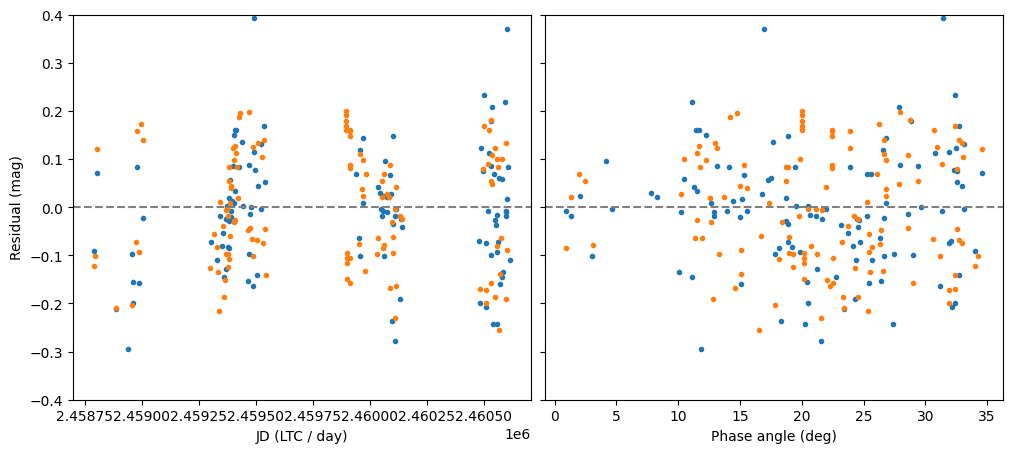

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for filtnum in pdf["i:fid"].unique():
    cond = pdf["i:fid"] == filtnum
    ax[0].plot(pdf["jd_ltc"][cond], pdf["residuals"][cond], ls="", marker=".")
    ax[1].plot(pdf["Phase"][cond], pdf["residuals"][cond], ls="", marker=".")

ax[0].axhline(0, ls="--", color="grey")
ax[1].axhline(0, ls="--", color="grey")

max_res = 0.4
ax[0].set_ylim(-max_res, max_res)
ax[0].set_xlabel("JD (LTC / day)")
ax[1].set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Residual (mag)")

mu, std 0    : 0.00  0.14
mu, std 1    : 0.00  0.14
mu, std All  : 0.00  0.14
a/b: 1.66
a/c: 1.75


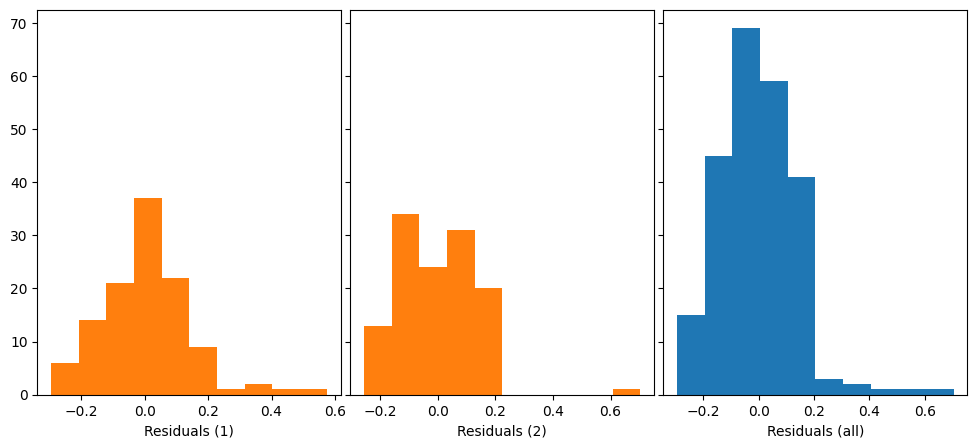

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    ax[i].hist(
        pdf["residuals"][cond],
    )
    ax[i].hist(
        pdf["residuals"][cond],
    )
    ax[i].set_xlabel(f"Residuals ({filtnum})")
    print(
        f'mu, std {i}    : {np.mean(pdf["residuals"][cond]):.2f}  {np.std(pdf["residuals"][cond]):.2f}'
    )

ax[2].hist(
    pdf["residuals"],
)
ax[2].set_xlabel(f"Residuals (all)")


print(f'mu, std All  : {np.mean(pdf["residuals"]):.2f}  {np.std(pdf["residuals"]):.2f}')

a_b, a_c = estimate_axes_ratio(pdf["residuals"], fit_shg1g2["R"])
print(f"a/b: {a_b:.2f}")
print(f"a/c: {a_c:.2f}")

## Estimate synodic to sidereal

In [19]:
jd = pdf["i:jd"].tolist()
jd2 = (pdf["i:jd"].values + 2 * period / 24.0).tolist()

eph = ssptools.ephemcc(name, jd, tcoor=2, observer="500")
eph2 = ssptools.ephemcc(name, jd2, tcoor=2, observer="500")

In [20]:
for i in range(len(jd)):
    eph.loc[i, "angle"] = angle_between_vectors(
        eph.loc[i, ["px", "py", "pz"]].values, eph2.loc[i, ["px", "py", "pz"]].values
    )

In [21]:
period

8.729975609545155

17.45995121909031 17.469086812390334 17.450815625790288


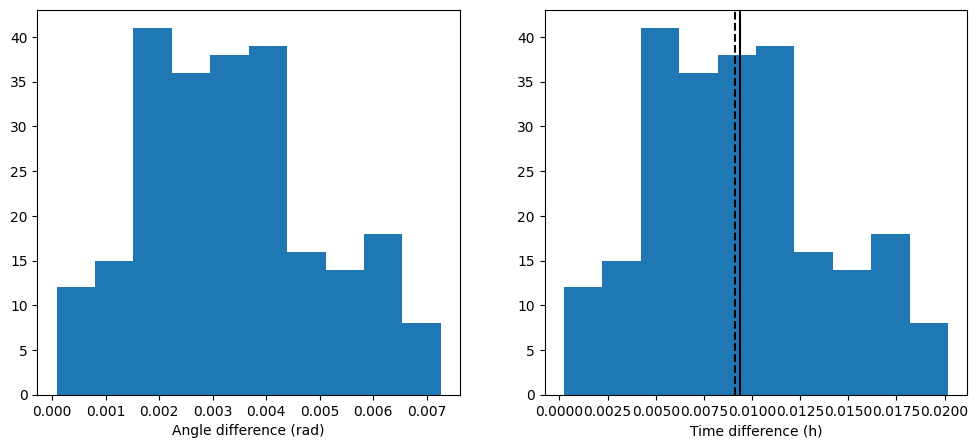

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(eph["angle"])

dephase = (eph["angle"] / (2 * np.pi)) * 2 * period
ax[1].hist(dephase)

ax[1].axvline( np.mean( dephase), color='black' )
ax[1].axvline( np.median( dephase), color='black', ls='dashed' )
# ax[1].axvline( np.mean( dephase), ls='dotted' )

ax[0].set_xlabel("Angle difference (rad)")
ax[1].set_xlabel("Time difference (h)")

print( 2*period, 2*period + np.median( dephase ), 2*period - np.median( dephase ) )

## ssHG1G2

In [23]:
# Sidereal Rotation in days (2* LS value: double-peaked lightcurve)
sidereal_period = synodic_to_sidereal(2 * period / 24.0, 000)
print(sidereal_period * 24)

17.45995121909031


In [26]:
# Test for 6605 to force initial value close to sidereal DAMIT
# sidereal_period = 118.69/24.
# print(sidereal_period*24)


# sidereal_period = 11.6027/24  # 5209
# sidereal_period = 12.2527/24 # 4209
sidereal_period = (2*period - np.median( dephase ))/24
sidereal_period = 27.47/24.

# Initial guess - V1
ra0 = np.radians(fit_shg1g2["alpha0"])
de0 = np.radians(fit_shg1g2["delta0"])
p0 = [
    fit_shg1g2["H_1"],
    fit_shg1g2["G1_1"],
    fit_shg1g2["G2_1"],
    ra0,
    de0,
    sidereal_period,
    a_b,
    a_c,
    0.0,
]

# Constrained Fit
fit_sshg1g2 = estimate_sso_parameters(
    pdf["i:magpsf_red"],
    pdf["i:sigmapsf"],
    np.radians(pdf["Phase"]),
    pdf["i:fid"],
    ra=np.radians(pdf["i:ra"]),
    dec=np.radians(pdf["i:dec"]),
    jd=pdf["jd_ltc"],
    model="SSHG1G2",
    p0=p0,
)

# Initial guess - V2: flipped spin
ra0 = (np.pi + np.radians(fit_shg1g2["alpha0"])) % (2 * np.pi)
de0 = -np.radians(fit_shg1g2["delta0"])
p0 = [
    fit_shg1g2["H_1"],
    fit_shg1g2["G1_1"],
    fit_shg1g2["G2_1"],
    ra0,
    de0,
    sidereal_period,
    a_b,
    a_c,
    0.0,
]

# Constrained Fit
fit_sshg1g2_alt = estimate_sso_parameters(
    pdf["i:magpsf_red"],
    pdf["i:sigmapsf"],
    np.radians(pdf["Phase"]),
    pdf["i:fid"],
    ra=np.radians(pdf["i:ra"]),
    dec=np.radians(pdf["i:dec"]),
    jd=pdf["jd_ltc"],
    model="SSHG1G2",
    p0=p0,
)

In [27]:
print("       sHG1G2  ssHG1G2  ss(alt)")
print(
    f"RMS  : {fit_shg1g2['rms']:6.3f}  {fit_sshg1g2['rms']:6.3f}  {fit_sshg1g2_alt['rms']:6.3f}"
)
print(
    f"chi2 : {fit_shg1g2['chi2red']:6.3f}  {fit_sshg1g2['chi2red']:6.3f}  {fit_sshg1g2_alt['chi2red']:6.3f}"
)
print()
print(
    f"H1   : {fit_shg1g2['H_1']:6.2f}  {fit_sshg1g2['H_1']:6.2f}  {fit_sshg1g2_alt['H_1']:6.2f}"
)
print(
    f"H2   : {fit_shg1g2['H_2']:6.2f}  {fit_sshg1g2['H_2']:6.2f}  {fit_sshg1g2_alt['H_2']:6.2f}"
)
print(
    f"G1_1 : {fit_shg1g2['G1_1']:6.2f}  {fit_sshg1g2['G1_1']:6.2f}  {fit_sshg1g2_alt['G1_1']:6.2f}"
)
print(
    f"G1_2 : {fit_shg1g2['G1_2']:6.2f}  {fit_sshg1g2['G1_2']:6.2f}  {fit_sshg1g2_alt['G1_2']:6.2f}"
)
print(
    f"G2_1 : {fit_shg1g2['G2_1']:6.2f}  {fit_sshg1g2['G2_1']:6.2f}  {fit_sshg1g2_alt['G2_1']:6.2f}"
)
print(
    f"G2_2 : {fit_shg1g2['G2_2']:6.2f}  {fit_sshg1g2['G2_2']:6.2f}  {fit_sshg1g2_alt['G2_2']:6.2f}"
)

print()
print(
    f"RA0  : {fit_shg1g2['alpha0']:6.1f}  {fit_sshg1g2['alpha0']:6.1f}  {fit_sshg1g2_alt['alpha0']:6.1f}"
)
print(
    f"DEC0 : {fit_shg1g2['delta0']:6.1f}  {fit_sshg1g2['delta0']:6.1f}  {fit_sshg1g2_alt['delta0']:6.1f}"
)
print(
    f"P(h) : {2*period:6.3f}  {fit_sshg1g2['period']*24:6.3f}  {fit_sshg1g2_alt['period']*24:6.3f}"
)
print(f"a/b  :         {fit_sshg1g2['a_b']:6.2f}  {fit_sshg1g2_alt['a_b']:6.2f}")
print(f"a/c  :         {fit_sshg1g2['a_c']:6.2f}  {fit_sshg1g2_alt['a_c']:6.2f}")


root = f"{num}_{name}".replace(" ", "_")
with open(os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}.csv"), "w") as f:
    f.write(f"par,sHG1G2,ssHG1G2,ssHG1G2_alt\n")
    f.write(f"RMS,{fit_shg1g2['rms']},{fit_sshg1g2['rms']},{fit_sshg1g2_alt['rms']}\n")
    f.write(
        f"chi2,{fit_shg1g2['chi2red']},{fit_sshg1g2['chi2red']},{fit_sshg1g2_alt['chi2red']}\n"
    )

    f.write(f"H_1,{fit_shg1g2['H_1']},{fit_sshg1g2['H_1']},{fit_sshg1g2_alt['H_1']}\n")
    f.write(
        f"err_H_1,{fit_shg1g2['err_H_1']},{fit_sshg1g2['err_H_1']},{fit_sshg1g2_alt['err_H_1']}\n"
    )
    f.write(
        f"G1_1,{fit_shg1g2['G1_1']},{fit_sshg1g2['G1_1']},{fit_sshg1g2_alt['G1_1']}\n"
    )
    f.write(
        f"G2_1,{fit_shg1g2['G2_1']},{fit_sshg1g2['G2_1']},{fit_sshg1g2_alt['G2_1']}\n"
    )
    f.write(
        f"err_G1_1,{fit_shg1g2['err_G1_1']},{fit_sshg1g2['err_G1_1']},{fit_sshg1g2_alt['err_G1_1']}\n"
    )
    f.write(
        f"err_G2_1,{fit_shg1g2['err_G2_1']},{fit_sshg1g2['err_G2_1']},{fit_sshg1g2_alt['err_G2_1']}\n"
    )

    f.write(f"H_2,{fit_shg1g2['H_2']},{fit_sshg1g2['H_2']},{fit_sshg1g2_alt['H_2']}\n")
    f.write(
        f"err_H_2,{fit_shg1g2['err_H_2']},{fit_sshg1g2['err_H_2']},{fit_sshg1g2_alt['err_H_2']}\n"
    )
    f.write(
        f"G1_2,{fit_shg1g2['G1_2']},{fit_sshg1g2['G1_2']},{fit_sshg1g2_alt['G1_2']}\n"
    )
    f.write(
        f"G2_2,{fit_shg1g2['G2_2']},{fit_sshg1g2['G2_2']},{fit_sshg1g2_alt['G2_2']}\n"
    )
    f.write(
        f"err_G1_2,{fit_shg1g2['err_G1_2']},{fit_sshg1g2['err_G1_2']},{fit_sshg1g2_alt['err_G1_2']}\n"
    )
    f.write(
        f"err_G2_2,{fit_shg1g2['err_G2_2']},{fit_sshg1g2['err_G2_2']},{fit_sshg1g2_alt['err_G2_2']}\n"
    )

    f.write(
        f"alpha0,{fit_shg1g2['alpha0']},{fit_sshg1g2['alpha0']},{fit_sshg1g2_alt['alpha0']}\n"
    )
    f.write(
        f"delta0,{fit_shg1g2['delta0']},{fit_sshg1g2['delta0']},{fit_sshg1g2_alt['delta0']}\n"
    )
    f.write(
        f"err_alpha0,{fit_shg1g2['err_alpha0']},{fit_sshg1g2['err_alpha0']},{fit_sshg1g2_alt['err_alpha0']}\n"
    )
    f.write(
        f"err_delta0,{fit_shg1g2['err_delta0']},{fit_sshg1g2['err_delta0']},{fit_sshg1g2_alt['err_delta0']}\n"
    )

    f.write(f"P,{2*period},{fit_sshg1g2['period']*24},{fit_sshg1g2_alt['period']*24}\n")
    f.write(f"a_b,,{fit_sshg1g2['a_b']},{fit_sshg1g2_alt['a_b']}\n")
    f.write(f"a_c,,{fit_sshg1g2['a_c']},{fit_sshg1g2_alt['a_c']}\n")
    f.write(
        f"err_P,{2*period},{fit_sshg1g2['err_period']*24},{fit_sshg1g2_alt['err_period']*24}\n"
    )
    f.write(f"err_a_b,,{fit_sshg1g2['err_a_b']},{fit_sshg1g2_alt['err_a_b']}\n")
    f.write(f"err_a_c,,{fit_sshg1g2['err_a_c']},{fit_sshg1g2_alt['err_a_c']}\n")

       sHG1G2  ssHG1G2  ss(alt)
RMS  :  0.138   0.092   0.085
chi2 : 20.280   9.059   7.602

H1   :  13.32   13.55   13.64
H2   :  12.59   12.81   12.92
G1_1 :   0.71    0.51    0.71
G1_2 :   0.48    0.30    0.57
G2_1 :   0.13    0.26    0.18
G2_2 :   0.25    0.36    0.25

RA0  :   93.8    78.2   269.7
DEC0 :    5.8   -24.8   -33.4
P(h) : 17.460  27.473  27.471
a/b  :           1.50    1.56
a/c  :           1.78    1.73


In [28]:
# --------------------------------------------------------------------------------
# Compute residuals
for filtnum in pdf["i:fid"].unique():

    # Input variables
    cond = pdf["i:fid"] == filtnum

    coord = SkyCoord(
        ra=pdf.loc[cond, "i:ra"], dec=pdf.loc[cond, "i:dec"], unit=("deg", "deg")
    )
    data_ra = coord.ra.rad
    data_dec = coord.dec.rad
    data_jd = pdf.loc[cond, "jd_ltc"]
    data_phase = np.radians(pdf.loc[cond, "Phase"])
    data_mag = pdf.loc[cond, "i:magpsf_red"]

    pha = [data_phase.values, data_ra, data_dec, data_jd.values]

    # ssHG1G2
    model = func_sshg1g2(
        pha,
        fit_sshg1g2[f"H_{filtnum}"],
        fit_sshg1g2[f"G1_{filtnum}"],
        fit_sshg1g2[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2["alpha0"]),
        np.radians(fit_sshg1g2["delta0"]),
        fit_sshg1g2["period"],
        fit_sshg1g2["a_b"],
        fit_sshg1g2["a_c"],
        fit_sshg1g2["phi0"],
    )

    model_alt = func_sshg1g2(
        pha,
        fit_sshg1g2_alt[f"H_{filtnum}"],
        fit_sshg1g2_alt[f"G1_{filtnum}"],
        fit_sshg1g2_alt[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2_alt["alpha0"]),
        np.radians(fit_sshg1g2_alt["delta0"]),
        fit_sshg1g2_alt["period"],
        fit_sshg1g2_alt["a_b"],
        fit_sshg1g2_alt["a_c"],
        fit_sshg1g2_alt["phi0"],
    )

    pdf.loc[cond, f"res_ssHG1G2"] = data_mag - model
    pdf.loc[cond, f"res_ssHG1G2_alt"] = data_mag - model_alt

/tmp/ipykernel_39824/1987799648.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


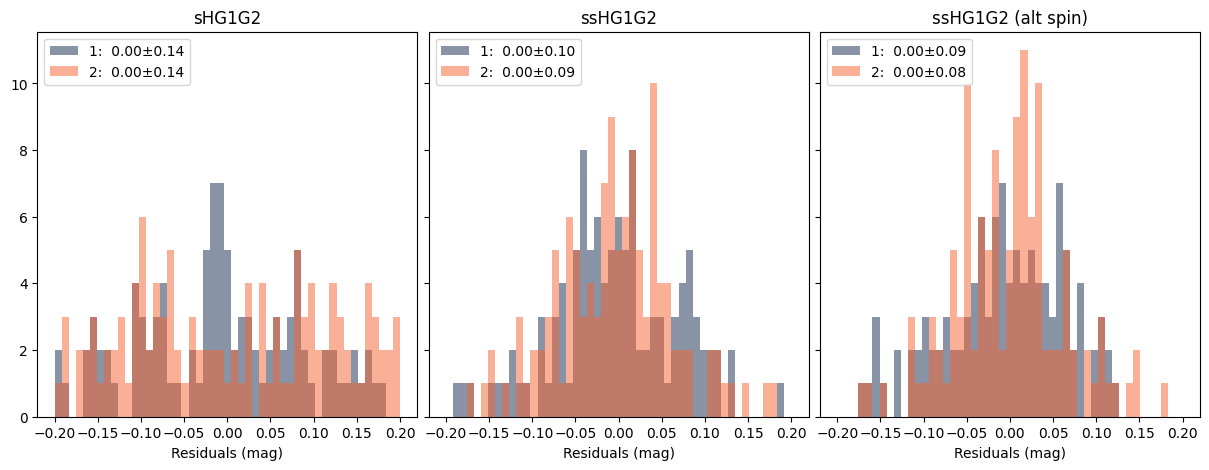

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

max_res = 0.2
bins = np.linspace(-max_res, max_res, 50)
for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    mu, std = np.mean(pdf.loc[cond, "residuals"]), np.std(pdf.loc[cond, "residuals"])
    ax[0].hist(
        pdf.loc[cond, "residuals"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )

    # V1
    mu, std = np.mean(pdf.loc[cond, "res_ssHG1G2"]), np.std(
        pdf.loc[cond, "res_ssHG1G2"]
    )
    ax[1].hist(
        pdf.loc[cond, "res_ssHG1G2"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )

    # V2 - alt
    mu, std = np.mean(pdf.loc[cond, "res_ssHG1G2_alt"]), np.std(
        pdf.loc[cond, "res_ssHG1G2_alt"]
    )
    ax[2].hist(
        pdf.loc[cond, "res_ssHG1G2_alt"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )


ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")
for a in ax:
    a.set_xlabel("Residuals (mag)")
    a.legend(loc="upper left")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_hist.png"),
    dpi=180,
    facecolor="white",
)

/tmp/ipykernel_39824/3275797286.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


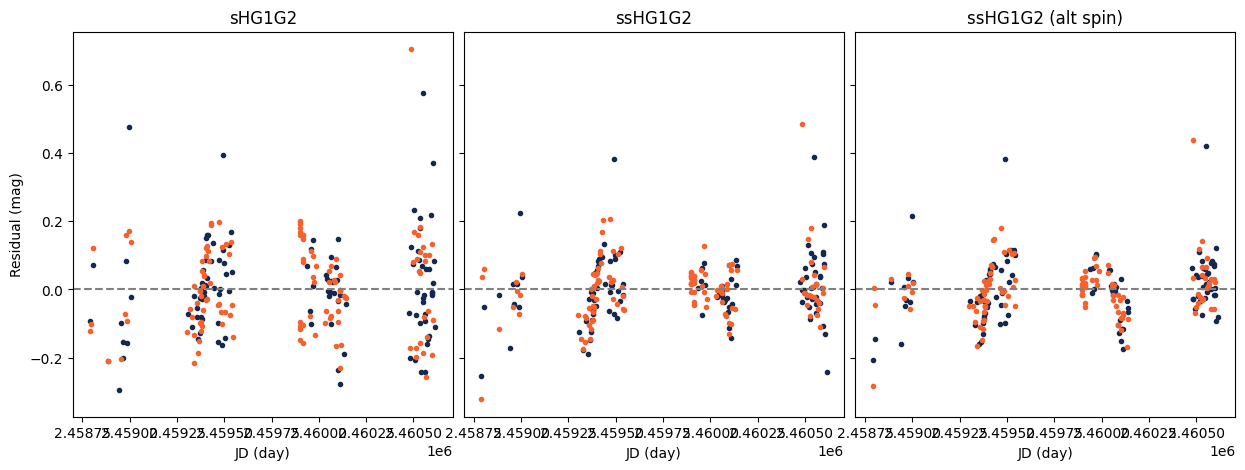

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    ax[0].scatter(
        pdf["i:jd"][cond],
        pdf["residuals"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[1].scatter(
        pdf["i:jd"][cond],
        pdf["res_ssHG1G2"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[2].scatter(
        pdf["i:jd"][cond],
        pdf["res_ssHG1G2_alt"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )

for a in ax:
    a.axhline(0, ls="--", color="grey")
    a.set_xlabel("JD (day)")
ax[0].set_ylabel("Residual (mag)")

ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_jd.png"),
    dpi=180,
    facecolor="white",
)

/tmp/ipykernel_39824/790428671.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


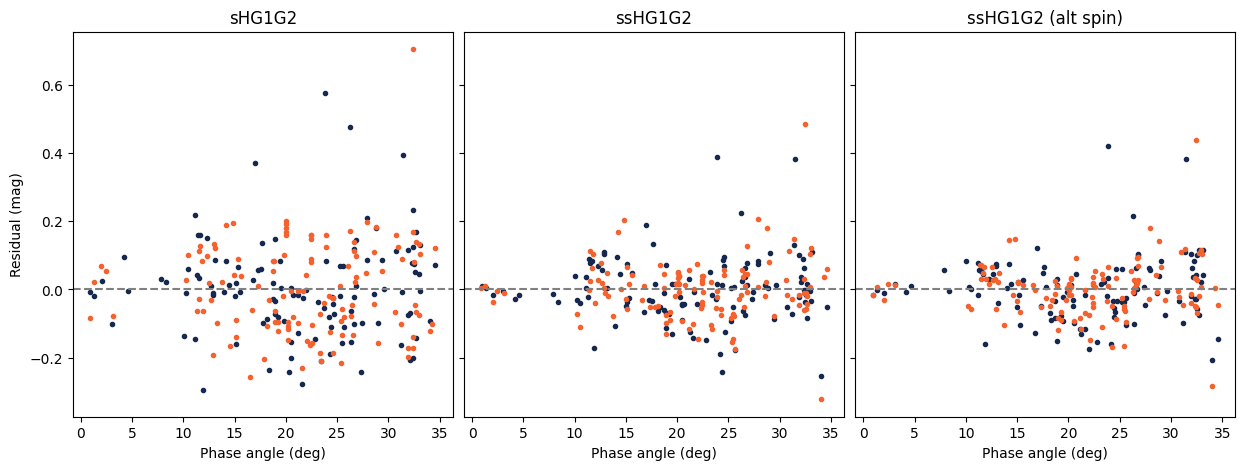

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    ax[0].scatter(
        pdf["Phase"][cond],
        pdf["residuals"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[1].scatter(
        pdf["Phase"][cond],
        pdf["res_ssHG1G2"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[2].scatter(
        pdf["Phase"][cond],
        pdf["res_ssHG1G2_alt"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )

for a in ax:
    a.axhline(0, ls="--", color="grey")
    a.set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Residual (mag)")

ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_phase.png"),
    dpi=180,
    facecolor="white",
)

In [32]:
num, name

(1139, 'Atami')

In [ ]:
from scipy.stats import kstest

for filtnum in [1, 2]:  # pdf["i:fid"].unique():
    cond = pdf["i:fid"] == filtnum

    ks_shgg = kstest(pdf["residuals"][cond], "norm")
    ks_sshgg = kstest(pdf["res_ssHG1G2"][cond], "norm")

    print(f"{filtnum}: sHG1G2: {ks_shgg.pvalue:.2e} -- ssHG1G2: {ks_sshgg.pvalue:.2e}")

In [ ]:
ks_shgg.pvalue, ks_sshgg.pvalue

In [ ]:
match ssnamenr:
    case 223:  # Example from article
        jd0 = 2459800
        t0 = jd0
        len_day = 30
        eph_large, eph_small = True, True
        jd1 = jd0 + 10
        step = "2h"
        nbd = 200

    case 186153:  # Example with high frequency observations
        jd0 = 2_460_495.550
        t0 = 2_460_495.50
        len_day = 1
        eph_large, eph_small = False, True
        jd1 = jd0
        step = "10m"
        nbd = 74

    case 136108:  # KBO slow mo
        jd0 = 2_460_050.5
        t0 = jd0
        len_day = 5
        eph_large, eph_small = True, True
        jd1 = jd0
        step = "10min"
        nbd = 700

    case 9799:  # JTO Thronium
        jd0 = 2_459_350
        t0 = jd0
        len_day = 30

        jd0 = 2_459_450
        t0 = jd0
        len_day = 50

        eph_large, eph_small = True, False
        jd1 = jd0
        step = "10min"
        nbd = 700

    case _:
        jd0 = 2_460_200.0
        t0 = jd0
        len_day = 100
        eph_large, eph_small = False, False
        jd1 = jd0
        step = "1h"
        nbd = 24


# --------------------------------------------------------------------------------
# Build independent variables
cond_jd = (pdf["i:jd"] > jd0) & (pdf["i:jd"] < jd0 + len_day)


fig, ax = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True, gridspec_kw={"wspace": 0.03}
)


# --------------------------------------------------------------------------------
# ssHG1G2
for i, filtnum in enumerate(pdf["i:fid"].unique()):

    # Input variables
    cond = cond_jd & (pdf["i:fid"] == filtnum)

    coord = SkyCoord(
        ra=pdf.loc[cond, "i:ra"], dec=pdf.loc[cond, "i:dec"], unit=("deg", "deg")
    )
    data_ra = coord.ra.rad
    data_dec = coord.dec.rad
    data_jd = pdf.loc[cond, "i:jd"]
    data_phase = np.radians(pdf.loc[cond, "Phase"])
    data_mag = pdf.loc[cond, "i:magpsf_red"]

    pha = [data_phase.values, data_ra, data_dec, data_jd.values]

    # DATA
    ax[0].scatter(
        data_jd,
        data_mag,
        marker="s",
        s=8,
        alpha=0.35,
        color=fink_colors[i],
        label="ZTF",
    )
    ax[1].scatter(
        data_jd,
        data_mag,
        marker="s",
        s=8,
        alpha=0.35,
        color=fink_colors[i],
        label="ZTF",
    )

    # sHG1G2
    model = func_hg1g2_with_spin(
        pha,
        fit_shg1g2[f"H_{filtnum}"],
        fit_shg1g2[f"G1_{filtnum}"],
        fit_shg1g2[f"G2_{filtnum}"],
        fit_shg1g2["R"],
        np.radians(fit_shg1g2["alpha0"]),
        np.radians(fit_shg1g2["delta0"]),
    )
    ax[0].scatter(
        data_jd,
        model,
        marker="o",
        s=8,
        alpha=1,
        color=fink_colors[i],
        label="sHG1G2",
    )

    # ssHG1G2
    model = func_sshg1g2(
        pha,
        fit_sshg1g2[f"H_{filtnum}"],
        fit_sshg1g2[f"G1_{filtnum}"],
        fit_sshg1g2[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2["alpha0"]),
        np.radians(fit_sshg1g2["delta0"]),
        fit_sshg1g2["period"],
        fit_sshg1g2["a_b"],
        fit_sshg1g2["a_c"],
        fit_sshg1g2["phi0"],
    )

    ax[1].scatter(
        data_jd,
        model,
        marker="o",
        s=8,
        alpha=1,
        color=fink_colors[i],
        label="ssHG1G2",
    )

# ax[1].scatter(data_phase, data_mag, ls="", marker=".", label="ZTF")
# ax[1].scatter(data_phase, model, ls="", marker=".", label="Model")
ax[0].set_xlabel("JD (day)")
ax[1].set_xlabel("JD (day)")
ax[0].set_ylabel("Reduced Magnitude")


# --------------------------------------------------------------------------------
# Long term behavior
if eph_large:
    eph = ssptools.ephemcc(ssnamenr, ep=jd0, step="6h", nbd=len_day * 4)
    f = 5 * np.log10(eph.Dobs * eph.Dhelio)

    coord = SkyCoord(ra=eph["RA"], dec=eph["DEC"], unit=("hour", "deg"))
    eph_ra = coord.ra.rad
    eph_dec = coord.dec.rad
    eph_phase = np.radians(eph["Phase"])
    eph_jd = eph["Date"]
    pha_eph = [eph_phase.values, eph_ra, eph_dec, eph_jd.values]

    for i, filtnum in enumerate(pdf["i:fid"].unique()):

        # sHG1G2
        model_eph = func_hg1g2_with_spin(
            pha,
            fit_shg1g2[f"H_{filtnum}"],
            fit_shg1g2[f"G1_{filtnum}"],
            fit_shg1g2[f"G2_{filtnum}"],
            fit_shg1g2["R"],
            np.radians(fit_shg1g2["alpha0"]),
            np.radians(fit_shg1g2["delta0"]),
        )
        ax[0].plot(
            data_jd,
            model_eph,
            ls="solid",
            color=fink_colors[i],
            # label=f"sHG1G2 {filtnum}",
        )

        # ssHG1G2
        model_eph = func_sshg1g2(
            pha_eph,
            fit_sshg1g2[f"H_{filtnum}"],
            fit_sshg1g2[f"G1_{filtnum}"],
            fit_sshg1g2[f"G2_{filtnum}"],
            np.radians(fit_sshg1g2["alpha0"]),
            np.radians(fit_sshg1g2["delta0"]),
            fit_sshg1g2["period"],
            fit_sshg1g2["a_b"],
            fit_sshg1g2["a_c"],
            fit_sshg1g2["phi0"],
        )

        ax[1].plot(
            eph_jd,
            model_eph,
            ls="solid",
            linewidth=1,
            alpha=0.5,
            color=fink_colors[i],
            # label=f"ssHG1G2 {filtnum}",
        )


# --------------------------------------------------------------------------------
# Short term behavior
if eph_small:
    eph2 = ssptools.ephemcc(ssnamenr, ep=jd1, step=step, nbd=nbd)
    f = 5 * np.log10(eph2.Dobs * eph2.Dhelio)

    coord = SkyCoord(ra=eph2["RA"], dec=eph2["DEC"], unit=("hour", "deg"))
    eph2_ra = coord.ra.rad
    eph2_dec = coord.dec.rad
    eph2_phase = np.radians(eph2["Phase"])
    eph2_jd = eph2["Date"]
    pha_eph2 = [eph2_phase.values, eph2_ra, eph2_dec, eph2_jd.values]

    model_eph2 = func_sshg1g2(
        pha_eph2,
        fit_sshg1g2[f"H_{filtnum}"],
        fit_sshg1g2[f"G1_{filtnum}"],
        fit_sshg1g2[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2["alpha0"]),
        np.radians(fit_sshg1g2["delta0"]),
        fit_sshg1g2["period"],
        fit_sshg1g2["a_b"],
        fit_sshg1g2["a_c"],
        fit_sshg1g2["phi0"],
    )
    ax[0].plot(eph2_jd, model_eph2, ls="--", alpha=0.5, color="C1", label="ST")
    ax[1].plot(eph2_phase, model_eph2, ls="--", alpha=0.5, color="C1", label="ST")

for a in ax:
    # a.legend()
    a.yaxis.set_inverted(True)

ax[0].legend(loc="best")
ax[1].legend(loc="best")
fig.suptitle(
    f"({nam_num[1]}) {nam_num[0]} - P={fit_sshg1g2['period']*24:.1f}h - a/b={fit_sshg1g2['a_b']:.2f} - a/c={fit_sshg1g2['a_c']:.2f}"
)

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_comparison.png"),
    dpi=180,
    facecolor="white",
)

In [ ]:
ssnamenr
# h, g1, g2, R, alpha0, delta0)